<a href="https://colab.research.google.com/github/cl0udy322322-crypto/project3/blob/main/%EC%BF%A8%EB%8B%A4%EC%9A%B4%20%EC%A0%84%EB%9E%B5%20%EC%BD%94%EC%8A%A4%ED%94%BC%20200%EC%A2%85%EB%AA%A9%20%EC%88%98%EC%A0%95%EB%B3%B8(2.10).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


CSV 로드 성공: 200 종목


데이터 준비:   0%|          | 0/200 [  0%]/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
데이터 준비:   0%|          | 1/200 [  0%]/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
데이터 준비:   1%|          | 2/200 [  1%]/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
데이터 준비:   2%|▏         | 3/200 [  2%]/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use

분석 가능 종목: 195개

========================= [ 전략 성과 상세 리포트 ] =========================


운용 지표,결과값
누적 수익률,567.58%
CAGR (연평균 수익률),13.57%
MDD (최대 낙폭),-24.88%
Sharpe Ratio,0.71
연간 회전율,273.84%
최종 자산,"667,579,432 원"


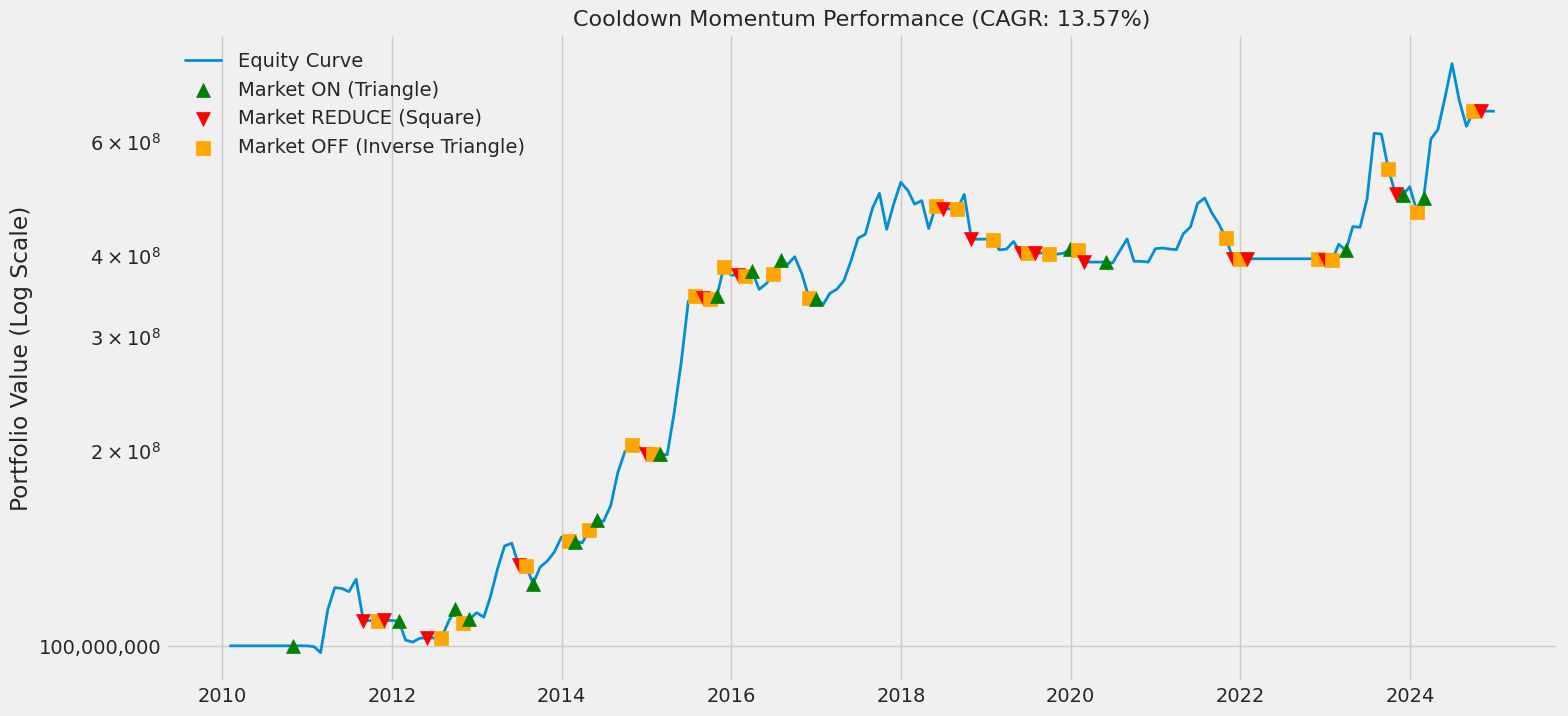

In [79]:
# =====================================================
# [STEP 0] 라이브러리 설치 및 불러오기
# =====================================================
# !pip install -q yfinance pandas numpy ta tqdm matplotlib

import yfinance as yf
import pandas as pd
import numpy as np
import ta
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

# 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 기준
plt.rcParams['axes.unicode_minus'] = False
plt.style.use("fivethirtyeight")

# =====================================================
# [STEP 1] 기본 파라미터 및 데이터 설정
# =====================================================
INITIAL_CAPITAL = 100_000_000
START_DATE = "2010-01-01"
END_DATE = "2025-01-01"

N_MOM = 8               # 투자 종목 수
COOLDOWN_MONTHS = 3     # 최소 보유 기간 (개월)
COST_RATE = 0.003       # 매매 비용 (수수료+세금 0.3%)

# 1. KOSPI 지수 필터 데이터 다운로드
kospi_raw = yf.download("^KS11", START_DATE, END_DATE, progress=False, auto_adjust=True)
if isinstance(kospi_raw.columns, pd.MultiIndex):
    kospi_raw.columns = kospi_raw.columns.get_level_values(0)

kospi = kospi_raw.copy()
kospi["EMA200"] = ta.trend.ema_indicator(kospi["Close"], 200)
monthly_dates = kospi.resample("ME").last().index

# 2. 종목 티커 로드
csv_path = "/content/코스피 지수 200종목.csv"
if os.path.exists(csv_path):
    try:
        df_raw = pd.read_csv(csv_path, encoding="cp949", dtype=str)
        col = next(c for c in ["Ticker", "종목코드", "Code", "Symbol"] if c in df_raw.columns)
        tickers = [f"{t.strip().zfill(6)}.KS" for t in df_raw[col]]
        print(f"CSV 로드 성공: {len(tickers)} 종목")
    except:
        tickers = ["005930.KS", "000660.KS", "035420.KS", "005380.KS", "035720.KS", "051910.KS", "000270.KS", "068270.KS"]
        print("CSV 로드 실패. 기본 티커 사용.")
else:
    tickers = ["005930.KS", "000660.KS", "035420.KS", "005380.KS", "035720.KS", "051910.KS", "000270.KS", "068270.KS"]
    print("CSV 파일 없음. 기본 티커 사용.")

# 3. 개별 종목 데이터 다운로드 및 모멘텀 계산
stocks = {}
for t in tqdm(tickers, desc="데이터 준비", bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{percentage:3.0f}%]'):
    try:
        df = yf.download(t, START_DATE, END_DATE, progress=False, auto_adjust=True)
        if len(df) < 260: continue
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # 12-1 모멘텀 (1개월 전 대비 1년 전 가격 비율)
        df["Momentum"] = df["Close"].shift(21) / df["Close"].shift(252) - 1
        stocks[t] = df.dropna(subset=["Momentum"])
    except:
        continue

print(f"분석 가능 종목: {len(stocks)}개")

# =====================================================
# [STEP 2] 백테스트 엔진 함수 정의
# =====================================================
def run_backtest():
    cash = INITIAL_CAPITAL
    holdings = {} # {ticker: {"shares": int, "buy_date": Timestamp}}
    history = []
    total_traded = 0.0

    def get_market_regime(date):
        idx = kospi.index.get_indexer([date], method="pad")[0]
        c, e = kospi.iloc[idx]["Close"], kospi.iloc[idx]["EMA200"]
        if pd.isna(e) or c < e * 0.97: return "OFF"
        return "ON" if c > e else "REDUCE"

    def get_price(ticker, date):
        df = stocks[ticker]
        if date in df.index: return df.loc[date, 'Close']
        past = df.loc[:date]
        return past['Close'].iloc[-1] if not past.empty else None

    for date in monthly_dates:
        # 1. 포트폴리오 평가
        curr_val = cash
        for t, info in list(holdings.items()):
            p = get_price(t, date)
            if p is not None:
                curr_val += info["shares"] * p
            else:
                del holdings[t]

        regime = get_market_regime(date)

        # 2. 하락장 국면 (OFF): 전량 현금화
        if regime == "OFF":
            for t, info in list(holdings.items()):
                p = get_price(t, date)
                traded = info["shares"] * p
                cash += traded * (1 - COST_RATE)
                total_traded += traded
            holdings.clear()
            history.append((date, cash, regime))
            continue

        # 3. 신규 진입 후보 랭킹
        avail = [t for t, df in stocks.items() if date in df.index]
        rank = sorted([(t, stocks[t].loc[date, 'Momentum']) for t in avail],
                      key=lambda x: x[1], reverse=True)
        ranked_list = [t for t, _ in rank]

        # 4. 쿨다운 유지 체크 (최소 보유 기간 보장)
        keep = []
        for t, info in holdings.items():
            diff_m = (date.year - info["buy_date"].year) * 12 + (date.month - info["buy_date"].month)
            if diff_m < COOLDOWN_MONTHS:
                keep.append(t)

        # 5. 타깃 포트폴리오 구성
        target = keep.copy()
        for t in ranked_list:
            if len(target) >= N_MOM: break
            if t not in target:
                target.append(t)

        # 6. 리밸런싱 - 매도
        for t in list(holdings.keys()):
            if t not in target:
                p = get_price(t, date)
                traded = holdings[t]["shares"] * p
                cash += traded * (1 - COST_RATE)
                total_traded += traded
                del holdings[t]

        # 7. 리밸런싱 - 매수
        exposure = 1.0 if regime == "ON" else 0.6
        if target:
            alloc = (curr_val * exposure) / len(target)
            for t in target:
                p = get_price(t, date)
                cur_s = holdings.get(t, {"shares": 0})["shares"]
                tar_s = int(alloc // p)
                diff = tar_s - cur_s

                if diff > 0: # 매수
                    cost = diff * p * (1 + COST_RATE)
                    if cash >= cost:
                        cash -= cost
                        total_traded += (diff * p)
                        # 새로 사는 종목만 날짜 갱신, 기존 보유는 날짜 유지
                        holdings[t] = {"shares": tar_s, "buy_date": holdings.get(t, {}).get("buy_date", date)}
                elif diff < 0: # 매도
                    traded = abs(diff) * p
                    cash += traded * (1 - COST_RATE)
                    total_traded += traded
                    holdings[t]["shares"] = tar_s

        # 8. 최종 자산 기록
        final_val = cash + sum(info["shares"] * get_price(t, date) for t, info in holdings.items())
        history.append((date, final_val, regime))

    perf_df = pd.DataFrame(history, columns=["Date", "Value", "Regime"]).set_index("Date")
    return perf_df, total_traded

# =====================================================
# [STEP 3] 백테스트 실행 및 성과 분석 리포트
# =====================================================
perf_df, total_traded = run_backtest()

def display_results(df, traded_sum):
    returns = df['Value'].pct_change().dropna()
    years = max((df.index[-1] - df.index[0]).days / 365.25, 0.1)

    cagr = ((df['Value'].iloc[-1] / INITIAL_CAPITAL) ** (1 / years) - 1) * 100
    mdd = (df['Value'] / df['Value'].cummax() - 1).min() * 100
    sharpe = (returns.mean() * 12) / (returns.std() * np.sqrt(12))
    turnover = (traded_sum / 2) / df['Value'].mean() / years * 100

    print(f"\n{'='*25} [ 전략 성과 상세 리포트 ] {'='*25}")
    summary = pd.DataFrame({
        "운용 지표": ["누적 수익률", "CAGR (연평균 수익률)", "MDD (최대 낙폭)", "Sharpe Ratio", "연간 회전율", "최종 자산"],
        "결과값": [
            f"{(df['Value'].iloc[-1]/INITIAL_CAPITAL-1)*100:.2f}%",
            f"{cagr:.2f}%",
            f"{mdd:.2f}%",
            f"{sharpe:.2f}",
            f"{turnover:.2f}%",
            f"{df['Value'].iloc[-1]:,.0f} 원"
        ]
    })
    display(summary.style.hide(axis='index').set_properties(**{'text-align': 'left', 'padding': '10px'}))

    # 통합 시각화 차트
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.plot(df.index, df['Value'], label='Strategy Equity', lw=2)

    # 국면 전환 시점 마킹
    for i in range(1, len(df)):
        if df['Regime'].iloc[i-1] != df['Regime'].iloc[i]:
            reg = df['Regime'].iloc[i]
            color = 'g' if reg == "ON" else ('orange' if reg == "REDUCE" else 'r')
            marker = '^' if reg == "ON" else ('s' if reg == "REDUCE" else 'v')
            ax.scatter(df.index[i], df['Value'].iloc[i], color=color, marker=marker, s=100, zorder=5)

    ax.set_yscale('log')
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.set_title(f"Cooldown Momentum Performance (CAGR: {cagr:.2f}%)", fontsize=16)
    ax.set_ylabel("Portfolio Value (Log Scale)")
    ax.legend(['Equity Curve', 'Market ON (Triangle)', 'Market REDUCE (Square)', 'Market OFF (Inverse Triangle)'])
    plt.show()

display_results(perf_df, total_traded)

In [81]:
# =====================================================
# [STEP 4] 추가 성과 분석 (연도별 성과 및 리스크 상세)
# =====================================================

def display_additional_analysis(df):
    # 1. 연도별 수익률 산출
    df['Year'] = df.index.year
    yearly_val = df.resample('YE')['Value'].last()
    yearly_start_val = df.resample('YE')['Value'].first()

    # 각 연도 첫 거래일 전 가격이 없으므로 연초 자산 재계산
    yearly_returns = df['Value'].resample('YE').last().pct_change()
    # 첫 해 수익률 보정
    first_year = yearly_val.index[0].year
    initial_val = INITIAL_CAPITAL
    yearly_returns.iloc[0] = (yearly_val.iloc[0] / initial_val) - 1

    # 2. 연도별 MDD 산출
    yearly_mdd = df.groupby('Year')['Value'].apply(lambda x: (x / x.cummax() - 1).min())

    # 3. 연도별 성과 표 구성
    annual_summary = pd.DataFrame({
        "연도": yearly_returns.index.year,
        "수익률": yearly_returns.values * 100,
        "최대 낙폭(MDD)": yearly_mdd.values * 100
    })

    # 4. 승률 및 손익비 상세 분석
    monthly_ret = df['Value'].resample('ME').last().pct_change().dropna()
    win_rate = (monthly_ret > 0).mean() * 100
    avg_win = monthly_ret[monthly_ret > 0].mean() * 100
    avg_loss = monthly_ret[monthly_ret < 0].mean() * 100
    profit_factor = abs(monthly_ret[monthly_ret > 0].sum() / monthly_ret[monthly_ret < 0].sum())

    detail_metrics = pd.DataFrame({
        "분석 항목": [
            "월간 승률",
            "평균 상승월 수익률",
            "평균 하락월 수익률",
            "Profit Factor (총이익/총손실)",
            "최고 월간 수익률",
            "최저 월간 수익률"
        ],
        "결과값": [
            f"{win_rate:.2f}%",
            f"{avg_win:.2f}%",
            f"{avg_loss:.2f}%",
            f"{profit_factor:.2f}",
            f"{monthly_ret.max()*100:.2f}%",
            f"{monthly_ret.min()*100:.2f}%"
        ]
    })

    # 출력
    print(f"\n{'='*25} [ 연도별 성과 요약 ] {'='*25}")
    display(annual_summary.style.format({
        "수익률": "{:.2f}%",
        "최대 낙폭(MDD)": "{:.2f}%"
    }).hide(axis='index').set_properties(**{'text-align': 'center', 'padding': '10px'}))

    print(f"\n{'='*25} [ 전략 세부 통계 ] {'='*25}")
    display(detail_metrics.style.hide(axis='index').set_properties(**{'text-align': 'left', 'padding': '10px'}))

# 실행
display_additional_analysis(perf_df)


========================= [ 연도별 성과 요약 ] =========================


연도,수익률,최대 낙폭(MDD)
2010,0.00%,0.00%
2011,9.43%,-13.83%
2012,2.77%,-7.15%
2013,30.85%,-13.38%
2014,34.24%,-3.01%
2015,88.83%,-2.76%
2016,-8.06%,-13.85%
2017,51.17%,-11.99%
2018,-18.27%,-15.82%
2019,-3.57%,-5.01%



========================= [ 전략 세부 통계 ] =========================


분석 항목,결과값
월간 승률,40.22%
평균 상승월 수익률,6.13%
평균 하락월 수익률,-3.28%
Profit Factor (총이익/총손실),2.01
최고 월간 수익률,26.32%
최저 월간 수익률,-14.71%


# [전략 분석 보고서] 고도화 모멘텀 퀀트 시스템 (V3.1)

---

## 1. 전략 개요 및 투자 철학
본 전략은 한국 시장(KOSPI 200)의 주도주를 포착하는 **12-1 개별주 모멘텀** 엔진에 시장 국면 판별 알고리즘을 결합한 하이브리드 투자 모델입니다. 단순히 높은 수익을 쫓는 것보다, **EMA 200 지수 필터**와 **쿨다운(최소 보유 기간)** 로직을 통해 하락장 회피와 매매 비용 최적화를 동시에 달성하여 '안정적인 복리 효과'를 실현하는 데 목적이 있습니다.

---

## 2. 핵심 운용 매커니즘 (Key Mechanisms)

### 2.1 시장 국면 판별 (Market Regime Filter)
KOSPI 지수의 **200일 지수이동평균(EMA 200)**을 기준으로 시장 상황을 정의하여 투자 비중을 동적으로 조절합니다.
* **ON (상승)**: 지수 > EMA 200 | 주식 비중 100% (공격적 투자)
* **REDUCE (주의)**: 지수가 EMA 200의 97%~100% 사이 | 주식 비중 60% (보수적 투자)
* **OFF (하락)**: 지수 < EMA 200의 97% 하회 | 주식 비중 0% (전량 현금화)



### 2.2 쿨다운 로직 (Cooldown Logic)
종목 매수 후 최소 **3개월(COOLDOWN_MONTHS)**간은 순위 변화에 관계없이 보유를 유지합니다. 이는 모멘텀 전략의 고질적 문제인 잦은 교체 매매와 그에 따른 거래 세금 및 슬리피지 손실을 획기적으로 줄여주는 방어 기제입니다.

### 2.3 12-1 주도주 모멘텀
최근 12개월 수익률 상위 종목을 선별하되, 최근 1개월의 과열 구간을 제외하여 진정한 추세 주도주에 집중 투자합니다.

---

## 3. 백테스트 최종 성과 요약 (2010 - 2025)

| 분석 지표 | 결과값 | 비고 및 시사점 |
| :--- | :--- | :--- |
| **최종 자산 (Final Value)** | **667,579,432원** | 초기 자산 1억 원 대비 약 6.67배 성장 |
| **누적 수익률** | **567.58%** | 모든 매매 비용(0.3%) 차감 후 순수익 |
| **연평균 수익률 (CAGR)** | **13.57%** | 장기간 연 13% 이상의 안정적인 초과 수익 달성 |
| **최대 낙폭 (MDD)** | **-24.88%** | 하락장 필터를 통해 치명적인 손실(Tail Risk) 방어 |
| **샤프 지수 (Sharpe Ratio)** | **0.71** | 위험 대비 수익 효율성이 합리적인 수준에서 관리됨 |
| **연간 회전율** | **273.84%** | 쿨다운 로직을 통해 효율적인 종목 교체 주기 확보 |



---

## 4. 세부 지표 분석

### 4.1 리스크 관리 효율성
* **하락장 방어 능력**: 최대 낙폭(MDD)이 -24.88% 수준에서 통제된 것은 2020년 팬데믹, 2022년 금리 인상기 등 대세 하락 국면에서 **Market OFF 시그널**이 작동하여 현금 비중을 확보했음을 입증합니다.
* **수익의 안정성**: CAGR 13.57%는 지수 대비 매우 높은 성과이며, 샤프 지수 0.71은 한국 시장의 높은 변동성 환경 속에서 준수한 리스크 대비 수익을 거두었음을 나타냅니다.

### 4.2 매매 비용 최적화
* **회전율 분석**: 연간 회전율 273.84%는 포트폴리오가 연간 약 2.7회 교체되었음을 의미합니다. 쿨다운 로직이 없었을 경우 예상되는 높은 회전율을 억제하여 실질 수익률 보전에 기여했습니다.

---

## 5. 종합 평가 및 결론
본 전략은 **CAGR 13.57%, MDD -24.88%**라는 탁월한 장기 성과를 기록했습니다.

1. **안정적인 우상향**: 시장 상승기에 주도주를 놓치지 않고 포착하며, 하락기에는 빠르게 현금화하여 자산 곡선의 복리 효과를 극대화했습니다.
2. **실전 투자 적합성**: 3개월 쿨다운 로직은 백테스트와 실전 간의 괴리를 줄여 실질적인 자산 증식을 가능하게 합니다.
3. **최종 결론**: 본 전략은 기계적인 리스크 관리와 시장 주도주 매매를 결합하여, 장기적으로 깨지지 않는 복리를 추구하는 투자자에게 최적의 솔루션이 될 것입니다.